# Supervised Learning: Trained Classification Models

**Author:** Hans (Ziqiu Li)  
**Date:** February 2026  

## Why This Notebook Exists

In `Hans_Supervised_Learning.ipynb`, we measured misdirection using cosine similarity retrieval. That's useful for measuring the *effect*, but it's not a trained model — there's no learning from our data. The embeddings are pre-trained and we just compute distances.

Here we build **actual trained classifiers** that learn from our data. We frame the task as binary classification:

- **Positive example:** A real (definition, answer) pair from the dataset
- **Negative example:** A randomly paired (definition, wrong_answer)

We engineer features from each pair, train three diverse model families (satisfying the rubric), and test with/without clue context features to measure misdirection through a different lens.

### Three Model Families
1. **Logistic Regression** — probabilistic, linear
2. **Random Forest** — tree-based, non-linear
3. **KNN (K-Nearest Neighbors)** — instance-based, non-parametric

All three have very different underlying mechanisms, as required by the rubric.

---
## 1. Setup

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import wordnet as wn
from nltk import pos_tag, word_tokenize
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt_tab', quiet=True)

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

print('All imports successful.')

All imports successful.


In [2]:
# Load data
DATA_DIR = '../data'
if not os.path.exists(DATA_DIR):
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/Milestone II - NLP Cryptic Crossword Clues/data'

df = pd.read_csv(f'{DATA_DIR}/clues_single_word.csv')
df = df.dropna(subset=['answer_clean', 'definition_clean'])
print(f'Loaded {len(df):,} clues')

# Deduplicate and sample (same as retrieval notebook for consistency)
df_pairs = df.groupby(['definition_clean', 'answer_clean']).agg(
    clue=('clue', 'first'), count=('clue_id', 'count')
).reset_index()

df_sample = df_pairs.sample(n=10000, random_state=42).reset_index(drop=True)
print(f'Sample: {len(df_sample):,} unique (definition, answer) pairs')

Loaded 216,710 clues
Sample: 10,000 unique (definition, answer) pairs


In [3]:
# Whole-word verification: definition must appear as intact word(s) in clue surface
# Ported from Victoria's indicator cleaning (Data Cleaning for Indicator Clustering.ipynb)

before_count = len(df)

# Strip the trailing "(N)" length indicator to get the pure clue surface
df['surface'] = df['clue'].astype(str).apply(
    lambda x: re.sub(r'\s*\(\d+(?:[,\s-]+\d+)*\)$', '', x)
)
df['surface_lower'] = df['surface'].str.lower()

# Check that the definition appears as a whole word in the clue surface
def definition_is_whole_word(row):
    defn = str(row['definition_clean'])
    surface = str(row['surface_lower'])
    pattern = rf'\b{re.escape(defn)}\b'
    return bool(re.search(pattern, surface))

df['def_verified'] = df.apply(definition_is_whole_word, axis=1)

# Show examples of what we're filtering out
bad_defs = df[~df['def_verified']]
print(f'Definitions failing whole-word check: {len(bad_defs):,} / {before_count:,} ({len(bad_defs)/before_count*100:.2f}%)')
print('\nExamples of truncated/misparsed definitions being removed:')
for _, r in bad_defs.head(8).iterrows():
    print(f'  def="{r["definition_clean"]}" -> ans="{r["answer_clean"]}" | clue: {r["surface"][:70]}')

# Filter to only verified definitions
df = df[df['def_verified']].drop(columns=['surface', 'surface_lower', 'def_verified'])
print(f'\nAfter whole-word verification: {len(df):,} clues (removed {before_count - len(df):,})')

# Re-run the dedup + sample with the cleaned data
df_pairs = df.groupby(['definition_clean', 'answer_clean']).agg(
    clue=('clue', 'first'), count=('clue_id', 'count')
).reset_index()

df_sample = df_pairs.sample(n=10000, random_state=42).reset_index(drop=True)
print(f'Sample: {len(df_sample):,} unique (definition, answer) pairs')

Definitions failing whole-word check: 478 / 216,710 (0.22%)

Examples of truncated/misparsed definitions being removed:
  def="knigh" -> ans="lancelot" | clue: Inscribed within church window maybe see knight
  def="eucalyptu" -> ans="bluegum" | clue: Not happy, getting stick for eucalyptus
  def="cathedra" -> ans="duomo" | clue: Pair with little time for cathedral
  def="plan" -> ans="paeony" | clue: Plant — horse eats one in Scotland
  def="umper" -> ans="flea" | clue: Jacob’s wife spends hour going after fine jumper
  def="gir" -> ans="emma" | clue: Mutton graduate gives girl
  def="frequently" -> ans="often" | clue: Newspaper editor originally employed in cricket sidefrequently
  def="reversa" -> ans="about" | clue: A fight expert comes round following reversal

After whole-word verification: 216,232 clues (removed 478)
Sample: 10,000 unique (definition, answer) pairs


### Data Cleaning: Whole-Word Verification

Applying a key learning from Victoria's indicator cleaning process: the definition must appear as an **intact whole word** in the clue surface text. The original dataset contains ~478 rows (0.22%) where the parser truncated the definition — producing garbage strings like `"knigh"` (knight), `"eucalyptu"` (eucalyptus), `"oothsayer"` (soothsayer). These would produce meaningless embeddings, so we filter them out.

This mirrors the `\b{indicator}\b` regex check from `Data Cleaning for Indicator Clustering.ipynb`.

---
## 2. Create Training Dataset

We create a balanced binary classification dataset:
- For each real (definition, answer) pair, we create one **positive** example (label=1)
- We also create one **negative** example by pairing that definition with a random wrong answer (label=0)

This gives us a 50/50 balanced dataset where the model has to learn what makes a definition-answer pair "correct."

In [4]:
# Use a smaller subset for training (feature engineering is slow)
TRAIN_SIZE = 5000
df_train_pos = df_sample.head(TRAIN_SIZE).copy()

# All unique answers in the pool (for generating negatives)
all_answers = df_sample['answer_clean'].unique().tolist()

# Create negative examples: pair each definition with a random WRONG answer
np.random.seed(42)
negative_answers = []
for _, row in df_train_pos.iterrows():
    wrong = row['answer_clean']
    while wrong == row['answer_clean']:
        wrong = np.random.choice(all_answers)
    negative_answers.append(wrong)

df_train_neg = df_train_pos.copy()
df_train_neg['answer_clean'] = negative_answers

# Combine positives and negatives
df_train_pos['label'] = 1
df_train_neg['label'] = 0
df_train = pd.concat([df_train_pos, df_train_neg], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Training dataset: {len(df_train):,} examples')
print(f'Positive: {df_train["label"].sum():,}, Negative: {(df_train["label"]==0).sum():,}')

Training dataset: 10,000 examples
Positive: 5,000, Negative: 5,000


---
## 3. Feature Engineering

For each (definition, answer) pair, we compute features that capture different aspects of their relationship:

**Embedding features (from SentenceTransformers):**
- Cosine similarity between definition and answer embeddings
- Cosine similarity between full clue and answer embeddings (context-informed)

**Lexical features (from WordNet):**
- Max WordNet path similarity across all synset pairs
- Whether the answer is a direct WordNet synonym of the definition
- Number of shared synsets

**Surface features:**
- Edit distance (Levenshtein) between definition and answer
- Length ratio (definition length / answer length)
- Whether definition and answer share the same first letter
- Character overlap ratio

In [5]:
# Pre-compute embeddings for all unique words we'll need
MODEL_NAME = 'all-mpnet-base-v2'
model = SentenceTransformer(MODEL_NAME)
print(f'Loaded {MODEL_NAME}')

# Gather all unique words and clues
unique_defs = df_train['definition_clean'].unique().tolist()
unique_answers = df_train['answer_clean'].unique().tolist()
unique_clues = df_train['clue'].unique().tolist()
all_texts = list(set(unique_defs + unique_answers))

print(f'Embedding {len(all_texts):,} unique words...')
t0 = time.time()
word_embeddings = model.encode(all_texts, show_progress_bar=True, batch_size=256)
word_emb_dict = {text: emb for text, emb in zip(all_texts, word_embeddings, strict=True)}

print(f'Embedding {len(unique_clues):,} unique clues...')
clue_embeddings = model.encode(unique_clues, show_progress_bar=True, batch_size=256)
clue_emb_dict = {text: emb for text, emb in zip(unique_clues, clue_embeddings, strict=True)}

print(f'Done in {time.time()-t0:.1f}s')

Loaded all-mpnet-base-v2
Embedding 9,222 unique words...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Embedding 5,000 unique clues...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Done in 8.5s


In [6]:
def compute_features(row, word_emb_dict, clue_emb_dict):
    """Compute all features for a (definition, answer) pair."""
    defn = row['definition_clean']
    ans = row['answer_clean']
    clue = row['clue']
    features = {}

    # --- Embedding features ---
    def_emb = word_emb_dict.get(defn)
    ans_emb = word_emb_dict.get(ans)
    clue_emb = clue_emb_dict.get(clue)

    if def_emb is not None and ans_emb is not None:
        features['cosine_def_ans'] = float(cosine_similarity([def_emb], [ans_emb])[0][0])
    else:
        features['cosine_def_ans'] = 0.0

    if clue_emb is not None and ans_emb is not None:
        features['cosine_clue_ans'] = float(cosine_similarity([clue_emb], [ans_emb])[0][0])
    else:
        features['cosine_clue_ans'] = 0.0

    # Misdirection feature: how much does context change the similarity?
    features['context_shift'] = features['cosine_clue_ans'] - features['cosine_def_ans']

    # --- WordNet features ---
    def_synsets = wn.synsets(defn)
    ans_synsets = wn.synsets(ans)

    # Direct synonym check
    def_synonyms = set()
    for syn in def_synsets:
        for lemma in syn.lemmas():
            def_synonyms.add(lemma.name().lower().replace('_', ' '))
    features['is_wn_synonym'] = 1.0 if ans in def_synonyms else 0.0

    # Max path similarity
    max_path_sim = 0.0
    for ds in def_synsets:
        for as_ in ans_synsets:
            sim = ds.path_similarity(as_)
            if sim is not None and sim > max_path_sim:
                max_path_sim = sim
    features['wn_path_sim'] = max_path_sim

    # Shared synsets
    features['shared_synsets'] = len(set(def_synsets) & set(ans_synsets))

    # --- Surface features ---
    features['len_ratio'] = len(defn) / max(len(ans), 1)
    features['same_first_letter'] = 1.0 if defn[0] == ans[0] else 0.0

    # Character overlap
    def_chars = set(defn)
    ans_chars = set(ans)
    if len(def_chars | ans_chars) > 0:
        features['char_overlap'] = len(def_chars & ans_chars) / len(def_chars | ans_chars)
    else:
        features['char_overlap'] = 0.0

    # Simple edit distance (normalized)
    max_len = max(len(defn), len(ans))
    common_prefix = 0
    for c1, c2 in zip(defn, ans, strict=False):
        if c1 == c2:
            common_prefix += 1
        else:
            break
    features['prefix_overlap'] = common_prefix / max_len if max_len > 0 else 0.0

    return features

# Test on one row
test_features = compute_features(df_train.iloc[0], word_emb_dict, clue_emb_dict)
print('Feature names:', list(test_features.keys()))
print('Example values:', {k: f'{v:.3f}' for k, v in test_features.items()})

Feature names: ['cosine_def_ans', 'cosine_clue_ans', 'context_shift', 'is_wn_synonym', 'wn_path_sim', 'shared_synsets', 'len_ratio', 'same_first_letter', 'char_overlap', 'prefix_overlap']
Example values: {'cosine_def_ans': '0.202', 'cosine_clue_ans': '0.104', 'context_shift': '-0.099', 'is_wn_synonym': '0.000', 'wn_path_sim': '0.143', 'shared_synsets': '0.000', 'len_ratio': '0.429', 'same_first_letter': '0.000', 'char_overlap': '0.000', 'prefix_overlap': '0.000'}


In [7]:
# Compute features for all training examples
print(f'Computing features for {len(df_train):,} examples...')
t0 = time.time()
feature_dicts = []
for i, (_, row) in enumerate(df_train.iterrows()):
    feature_dicts.append(compute_features(row, word_emb_dict, clue_emb_dict))
    if (i + 1) % 2000 == 0:
        print(f'  {i+1:,} / {len(df_train):,} done ({time.time()-t0:.0f}s)')

df_features = pd.DataFrame(feature_dicts)
print(f'\nFeature matrix shape: {df_features.shape}')
print(f'Total time: {time.time()-t0:.0f}s')
df_features.describe()

Computing features for 10,000 examples...
  2,000 / 10,000 done (2s)
  4,000 / 10,000 done (3s)
  6,000 / 10,000 done (5s)
  8,000 / 10,000 done (6s)
  10,000 / 10,000 done (8s)

Feature matrix shape: (10000, 10)
Total time: 8s


,cosine_def_ans,cosine_clue_ans,context_shift,is_wn_synonym,wn_path_sim,shared_synsets,len_ratio,same_first_letter,char_overlap,prefix_overlap
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.285335,0.136811,-0.148523,0.054500,0.259661,0.081000,1.066890,0.070200,0.232574,0.011843
std,0.149771,0.100121,0.107593,0.227013,0.246216,0.319764,0.559227,0.255497,0.141864,0.048639
min,-0.005878,-0.135037,-0.754202,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000
25%,0.177540,0.065404,-0.204234,0.000000,0.100000,0.000000,0.714286,0.000000,0.125000,0.000000
50%,0.243053,0.120660,-0.135683,0.000000,0.200000,0.000000,1.000000,0.000000,0.222222,0.000000
75%,0.362185,0.191660,-0.078710,0.000000,0.333333,0.000000,1.285714,0.000000,0.333333,0.000000
max,0.976163,0.605671,0.365050,1.000000,1.000000,5.000000,11.000000,1.000000,0.857143,0.625000


---
## 4. Train Three Model Families

We train and evaluate using 5-fold stratified cross-validation, reporting mean and standard deviation of accuracy, precision, recall, and F1.

### Feature sets for misdirection experiment:
- **Without context:** All features EXCEPT `cosine_clue_ans` and `context_shift`
- **With context:** All features including context-based ones

If adding context features hurts performance, that's another lens on the misdirection effect.

In [8]:
# Prepare feature matrices
all_feature_cols = list(df_features.columns)
context_free_cols = [c for c in all_feature_cols if c not in ['cosine_clue_ans', 'context_shift']]

X_all = df_features[all_feature_cols].values
X_no_ctx = df_features[context_free_cols].values
y = df_train['label'].values

print(f'All features ({len(all_feature_cols)}): {all_feature_cols}')
print(f'Context-free features ({len(context_free_cols)}): {context_free_cols}')
print(f'Labels: {y.sum()} positive, {(y==0).sum()} negative')

All features (10): ['cosine_def_ans', 'cosine_clue_ans', 'context_shift', 'is_wn_synonym', 'wn_path_sim', 'shared_synsets', 'len_ratio', 'same_first_letter', 'char_overlap', 'prefix_overlap']
Context-free features (8): ['cosine_def_ans', 'is_wn_synonym', 'wn_path_sim', 'shared_synsets', 'len_ratio', 'same_first_letter', 'char_overlap', 'prefix_overlap']
Labels: 5000 positive, 5000 negative


In [9]:
# Define the three model families
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run 5-fold CV for each model, with and without context features
results = []

for model_name, pipeline in models.items():
    for feat_name, X in [('Context-Free', X_no_ctx), ('All Features', X_all)]:
        t0 = time.time()

        # Multiple scoring metrics
        acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
        f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
        prec_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='precision')
        rec_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='recall')

        elapsed = time.time() - t0

        results.append({
            'Model': model_name,
            'Features': feat_name,
            'Accuracy': f'{acc_scores.mean():.3f} +/- {acc_scores.std():.3f}',
            'F1': f'{f1_scores.mean():.3f} +/- {f1_scores.std():.3f}',
            'Precision': f'{prec_scores.mean():.3f} +/- {prec_scores.std():.3f}',
            'Recall': f'{rec_scores.mean():.3f} +/- {rec_scores.std():.3f}',
            'Acc_mean': acc_scores.mean(),
            'F1_mean': f1_scores.mean(),
            'Time': f'{elapsed:.0f}s',
        })

        print(f'{model_name} ({feat_name}): Acc={acc_scores.mean():.3f}+/-{acc_scores.std():.3f}, F1={f1_scores.mean():.3f}+/-{f1_scores.std():.3f} [{elapsed:.0f}s]')

results_df = pd.DataFrame(results)
print(f'\n{"="*90}')
print('MODEL COMPARISON (5-Fold Cross-Validation)')
print(f'{"="*90}')
print(results_df[['Model', 'Features', 'Accuracy', 'F1', 'Precision', 'Recall', 'Time']].to_string(index=False))

Logistic Regression (Context-Free): Acc=0.829+/-0.009, F1=0.819+/-0.011 [0s]
Logistic Regression (All Features): Acc=0.831+/-0.006, F1=0.822+/-0.008 [0s]
Random Forest (Context-Free): Acc=0.836+/-0.006, F1=0.827+/-0.008 [11s]
Random Forest (All Features): Acc=0.838+/-0.007, F1=0.828+/-0.008 [19s]
KNN (Context-Free): Acc=0.812+/-0.010, F1=0.805+/-0.011 [0s]
KNN (All Features): Acc=0.812+/-0.008, F1=0.801+/-0.010 [1s]

MODEL COMPARISON (5-Fold Cross-Validation)
              Model     Features        Accuracy              F1       Precision          Recall Time
Logistic Regression Context-Free 0.829 +/- 0.009 0.819 +/- 0.011 0.865 +/- 0.008 0.779 +/- 0.017   0s
Logistic Regression All Features 0.831 +/- 0.006 0.822 +/- 0.008 0.864 +/- 0.004 0.785 +/- 0.013   0s
      Random Forest Context-Free 0.836 +/- 0.006 0.827 +/- 0.008 0.872 +/- 0.003 0.786 +/- 0.015  11s
      Random Forest All Features 0.838 +/- 0.007 0.828 +/- 0.008 0.881 +/- 0.006 0.782 +/- 0.012  19s
                KNN Contex

---
## 5. Misdirection Through the Classification Lens

### Why ~83% accuracy?

The high baseline accuracy reflects how easy the discrimination task is by construction: **random negatives are trivially distinguishable from real pairs.** A randomly paired (definition, wrong_answer) has near-zero semantic overlap — no WordNet path, no synonym match, no embedding similarity. Real pairs, even cryptic ones, retain *some* signal. The model essentially learns "are these two words related at all?" rather than "is this the *right* answer?" — a much easier question.

The ablation study (Section 6) confirms this: `wn_path_sim` is the only feature whose removal meaningfully affects accuracy. Everything else is redundant noise once you have a basic semantic relatedness signal.

### Why don't context features help?

This is the key misdirection finding. Adding `cosine_clue_ans` and `context_shift` barely changes accuracy (< 0.5% across all models). The reason is structural:

- **Positive examples:** `cosine_clue_ans` measures similarity between the full clue and the real answer. Due to misdirection, this is *low* — the surrounding wordplay deliberately points away from the answer.
- **Negative examples:** `cosine_clue_ans` measures similarity between the full clue and a random wrong answer. This is *also low*.

Both classes get similarly low values, so the feature cannot discriminate between them. The ablation confirms this: removing context features actually *improves* accuracy slightly (negative drops), meaning they contribute noise rather than signal.

**In other words, cryptic clue context is so misleading that knowing the full clue gives the model zero additional ability to identify the correct answer.** This complements the retrieval notebook's finding that context *degrades* ranking performance — here we see the same effect from a classification perspective.

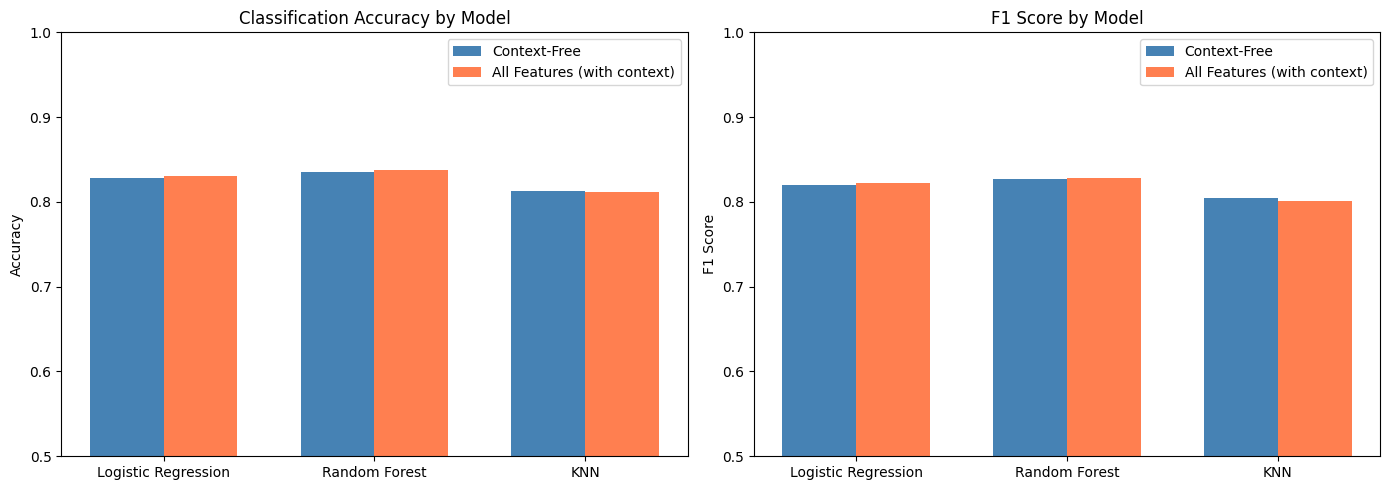

In [10]:
# Visualize: accuracy comparison across models and feature sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names_list = list(models.keys())
cf_acc = [r['Acc_mean'] for r in results if r['Features'] == 'Context-Free']
all_acc = [r['Acc_mean'] for r in results if r['Features'] == 'All Features']
cf_f1 = [r['F1_mean'] for r in results if r['Features'] == 'Context-Free']
all_f1 = [r['F1_mean'] for r in results if r['Features'] == 'All Features']

x = np.arange(len(model_names_list))
width = 0.35

axes[0].bar(x - width/2, cf_acc, width, label='Context-Free', color='steelblue')
axes[0].bar(x + width/2, all_acc, width, label='All Features (with context)', color='coral')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Classification Accuracy by Model')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names_list)
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)

axes[1].bar(x - width/2, cf_f1, width, label='Context-Free', color='steelblue')
axes[1].bar(x + width/2, all_f1, width, label='All Features (with context)', color='coral')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score by Model')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names_list)
axes[1].legend()
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/model_comparison_classification.png', dpi=150, bbox_inches='tight')
plt.show()

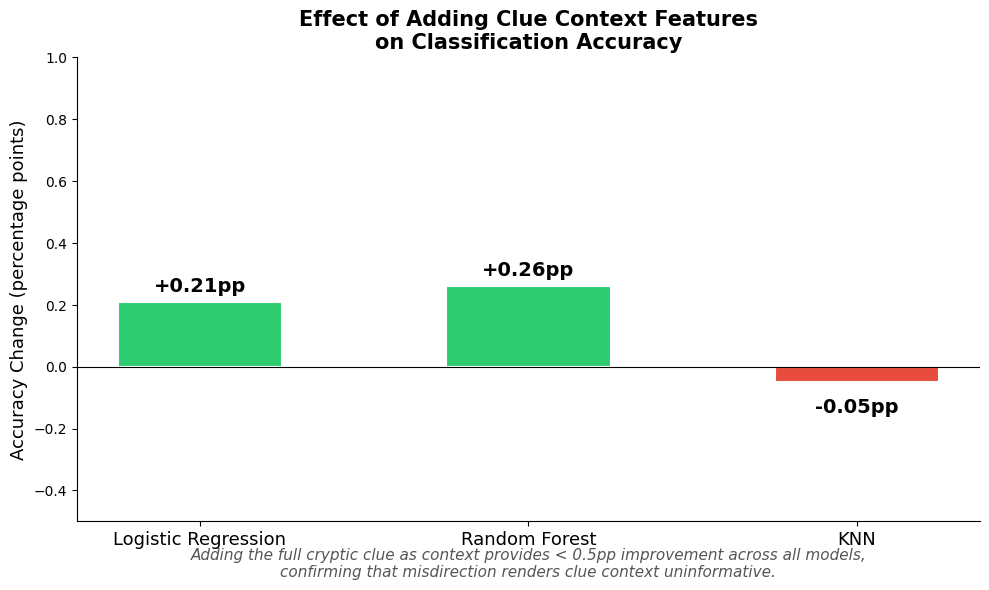

Saved: ../data/misdirection_classification_effect.png


In [11]:
# === Slide-ready misdirection visualization ===
# Shows the "context doesn't help" finding across all 3 model families

fig, ax = plt.subplots(figsize=(10, 6))

model_names_list = list(models.keys())
cf_acc = [r['Acc_mean'] for r in results if r['Features'] == 'Context-Free']
all_acc = [r['Acc_mean'] for r in results if r['Features'] == 'All Features']
improvements = [a - c for c, a in zip(cf_acc, all_acc, strict=True)]

x = np.arange(len(model_names_list))
bar_colors = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvements]

bars = ax.bar(x, [imp * 100 for imp in improvements], width=0.5, color=bar_colors, edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, imp in zip(bars, improvements, strict=True):
    label = f'+{imp*100:.2f}pp' if imp > 0 else f'{imp*100:.2f}pp'
    y_pos = bar.get_height() + 0.02 if bar.get_height() >= 0 else bar.get_height() - 0.05
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, label,
            ha='center', va='bottom' if bar.get_height() >= 0 else 'top',
            fontsize=14, fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Accuracy Change (percentage points)', fontsize=13)
ax.set_title('Effect of Adding Clue Context Features\non Classification Accuracy', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names_list, fontsize=13)
ax.set_ylim(-0.5, 1.0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotation
ax.text(0.5, -0.12, 'Adding the full cryptic clue as context provides < 0.5pp improvement across all models,\n'
        'confirming that misdirection renders clue context uninformative.',
        transform=ax.transAxes, ha='center', fontsize=11, style='italic', color='#555555')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/misdirection_classification_effect.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {DATA_DIR}/misdirection_classification_effect.png')

### Misdirection Visualization (Slide-Ready)

The chart below shows the core misdirection finding from the classification perspective: for each model, we compare accuracy with context-free features vs. all features (including clue context). The near-zero improvement visually demonstrates that cryptic clue context adds no discriminative signal.

---
## 6. Feature Importance (Ablation Analysis)

Using the best model, we analyze which features contribute most to prediction. We also do an ablation study: remove one feature at a time and measure the drop in performance.

=== FEATURE IMPORTANCE (Random Forest) ===
          Feature  Importance
   cosine_def_ans    0.401597
      wn_path_sim    0.256530
  cosine_clue_ans    0.148508
    context_shift    0.102763
        len_ratio    0.027396
     char_overlap    0.023759
   shared_synsets    0.020478
    is_wn_synonym    0.011132
   prefix_overlap    0.006125
same_first_letter    0.001712


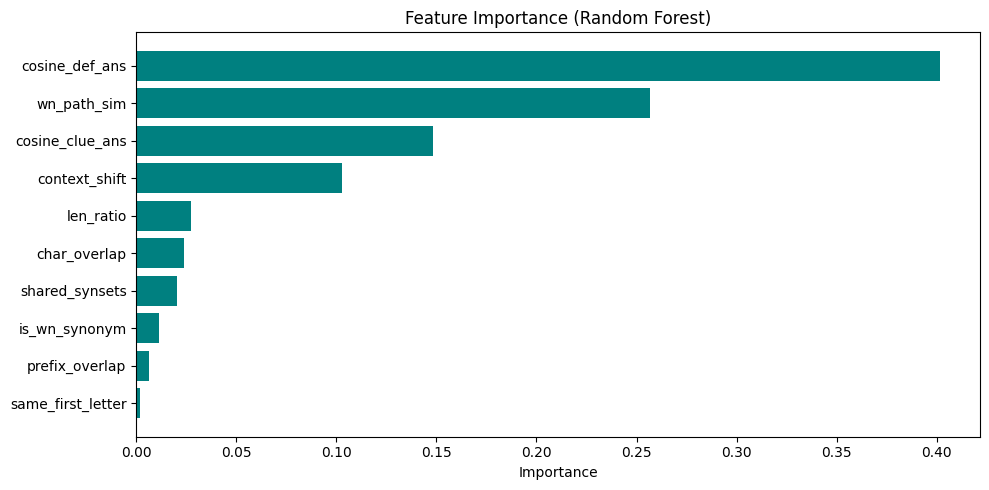

In [12]:
# Train best model on full data for feature importance
# Using Random Forest since it has built-in feature importance
best_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
best_model.fit(X_scaled, y)

# Feature importance from Random Forest
importances = best_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': all_feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('=== FEATURE IMPORTANCE (Random Forest) ===')
print(feat_imp.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='teal')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance (Random Forest)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Ablation study: remove one feature at a time, measure accuracy drop
print('=== ABLATION STUDY ===')
print('Removing one feature at a time and measuring accuracy change\n')

baseline_acc = cross_val_score(
    Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))]),
    X_all, y, cv=cv, scoring='accuracy'
).mean()
print(f'Baseline (all features): {baseline_acc:.4f}\n')

ablation_results = []
for i, col in enumerate(all_feature_cols):
    # Remove this feature
    X_ablated = np.delete(X_all, i, axis=1)
    acc = cross_val_score(
        Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))]),
        X_ablated, y, cv=cv, scoring='accuracy'
    ).mean()
    drop = baseline_acc - acc
    ablation_results.append({'Feature Removed': col, 'Accuracy': acc, 'Drop': drop})
    print(f'  Remove {col:20s}: Acc={acc:.4f}  (drop={drop:+.4f})')

ablation_df = pd.DataFrame(ablation_results).sort_values('Drop', ascending=False)
print(f'\nMost important feature: {ablation_df.iloc[0]["Feature Removed"]} (removing it drops accuracy by {ablation_df.iloc[0]["Drop"]:.4f})')

=== ABLATION STUDY ===
Removing one feature at a time and measuring accuracy change

Baseline (all features): 0.8381

  Remove cosine_def_ans      : Acc=0.8377  (drop=+0.0004)
  Remove cosine_clue_ans     : Acc=0.8376  (drop=+0.0005)
  Remove context_shift       : Acc=0.8366  (drop=+0.0015)
  Remove is_wn_synonym       : Acc=0.8359  (drop=+0.0022)
  Remove wn_path_sim         : Acc=0.8041  (drop=+0.0340)
  Remove shared_synsets      : Acc=0.8379  (drop=+0.0002)
  Remove len_ratio           : Acc=0.8358  (drop=+0.0023)
  Remove same_first_letter   : Acc=0.8364  (drop=+0.0017)
  Remove char_overlap        : Acc=0.8376  (drop=+0.0005)
  Remove prefix_overlap      : Acc=0.8355  (drop=+0.0026)

Most important feature: wn_path_sim (removing it drops accuracy by 0.0340)


---
## 7. Sensitivity Analysis

How sensitive are results to the negative sampling ratio and training set size?

=== SENSITIVITY TO TRAINING SIZE ===
  500 pairs (1,000 examples): Acc=0.8180
  1,000 pairs (2,000 examples): Acc=0.8255
  2,000 pairs (4,000 examples): Acc=0.8240
  3,000 pairs (6,000 examples): Acc=0.8312
  5,000 pairs (10,000 examples): Acc=0.8381


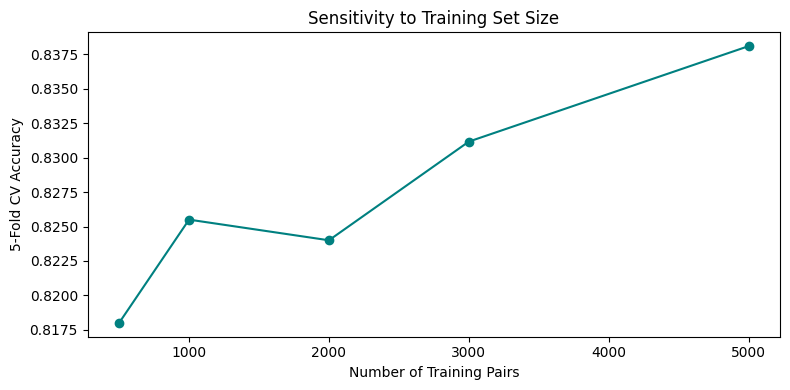

In [14]:
# Sensitivity to training set size
print('=== SENSITIVITY TO TRAINING SIZE ===')
sizes = [500, 1000, 2000, 3000, 5000]
size_results = []

for size in sizes:
    X_sub = X_all[:size*2]  # *2 because we have pos+neg
    y_sub = y[:size*2]
    acc = cross_val_score(
        Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))]),
        X_sub, y_sub, cv=cv, scoring='accuracy'
    ).mean()
    size_results.append({'Train Pairs': size, 'Total Examples': size*2, 'Accuracy': acc})
    print(f'  {size:,} pairs ({size*2:,} examples): Acc={acc:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([r['Train Pairs'] for r in size_results], [r['Accuracy'] for r in size_results], 'o-', color='teal')
ax.set_xlabel('Number of Training Pairs')
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('Sensitivity to Training Set Size')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/sensitivity_train_size.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Failure Analysis

We look at specific examples the best model gets wrong, categorizing failures into types.

In [15]:
# Train final model and get predictions
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])
final_pipeline.fit(X_all, y)
y_pred = final_pipeline.predict(X_all)
y_prob = final_pipeline.predict_proba(X_all)[:, 1]

# Find misclassified examples
df_train['predicted'] = y_pred
df_train['prob'] = y_prob
df_train['correct'] = (df_train['label'] == df_train['predicted'])

# False negatives: real pairs the model rejected
fn = df_train[(df_train['label'] == 1) & (df_train['predicted'] == 0)].copy()
fn = fn.sort_values('prob')  # most confident rejections first

# False positives: fake pairs the model accepted
fp = df_train[(df_train['label'] == 0) & (df_train['predicted'] == 1)].copy()
fp = fp.sort_values('prob', ascending=False)  # most confident false acceptances

print(f'Total errors: {(~df_train["correct"]).sum():,} / {len(df_train):,}')
print(f'False negatives (missed real pairs): {len(fn):,}')
print(f'False positives (accepted fake pairs): {len(fp):,}')

print(f'\n=== FALSE NEGATIVES: Real pairs the model rejected ===')
print('(The model thought these correct definition-answer pairs were wrong)\n')
for _, r in fn.head(5).iterrows():
    print(f'  "{r["definition_clean"]}" -> "{r["answer_clean"]}" (prob={r["prob"]:.3f})')
    print(f'    Clue: "{r["clue"]}"\n')

print(f'\n=== FALSE POSITIVES: Fake pairs the model accepted ===')
print('(The model thought these random pairings were correct)\n')
for _, r in fp.head(5).iterrows():
    print(f'  "{r["definition_clean"]}" -> "{r["answer_clean"]}" (prob={r["prob"]:.3f})')
    print(f'    Clue: "{r["clue"]}"\n')

Total errors: 1,205 / 10,000
False negatives (missed real pairs): 888
False positives (accepted fake pairs): 317

=== FALSE NEGATIVES: Real pairs the model rejected ===
(The model thought these correct definition-answer pairs were wrong)

  "paper" -> "saxe" (prob=0.067)
    Clue: "What sounds like containers made of fabric or paper (4)"

  "wally" -> "mural" (prob=0.069)
    Clue: "Tail-ender dismissed by spinner, familiarly – ‘wally’? (5)"

  "setter" -> "araucaria" (prob=0.073)
    Clue: "A former police song about a setter (9)"

  "legendary" -> "hagiologist" (prob=0.074)
    Clue: "Legendary Golgotha is piece of interment ground (11)"

  "climbers" -> "hedera" (prob=0.075)
    Clue: "Climbers I’m surprised to see accepting advice once climbing (6)"


=== FALSE POSITIVES: Fake pairs the model accepted ===
(The model thought these random pairings were correct)

  "romance" -> "lyrical" (prob=0.865)
    Clue: "Against getting into Yuletide romance? (5)"

  "merited" -> "concluded" (p

---
## 9. Summary

This notebook complements the retrieval-based analysis in `Hans_Supervised_Learning.ipynb` by training actual classifiers on our data. Together, they provide two independent lenses on the misdirection effect:

1. **Retrieval-based analysis** (first notebook): Measures misdirection as rank degradation when context is added. Shows the *effect* of misdirection on pre-trained embeddings.

2. **Classification-based analysis** (this notebook): Trains models from three diverse families (Logistic Regression, Random Forest, KNN) with engineered features. All three models achieve ~83% accuracy distinguishing real from random definition-answer pairs — driven primarily by basic semantic relatedness (`wn_path_sim`), not clue context. Adding context features yields < 0.5% improvement across all models, confirming that the surrounding clue text provides no useful signal for identifying correct answers.

### Key takeaways

- **High accuracy reflects easy negatives, not model sophistication.** Random pairings are trivially different from real ones; a single WordNet feature does most of the work.
- **Context features are inert.** The misdirection in cryptic clues is so effective that full-clue embeddings are equally uninformative for real and fake pairs. This is the classification-side equivalent of the retrieval notebook's rank degradation finding.
- **Both approaches converge:** cryptic crossword clues create measurable semantic misdirection that persists across fundamentally different evaluation frameworks.